In [46]:
# ── View aligned outputs in napari ─────────────────────────────────────────────
import napari
import numpy as np
from pathlib import Path


# Point at one image's output folder
# view_dir = Path(r"Z:\Bel\Vascumap_Outputs\marina_M4_2025.02.28_FL32_FL33_img19_Bead_Merged" )
view_dir = Path("Z:\Bel\Vascumap_Outputs\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_only_v3_Merged")
npy_files = sorted(view_dir.glob("*.npy"))
for i in range(len(npy_files)):
    print(i, npy_files[i])


0 Z:\Bel\Vascumap_Outputs\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_only_v3_Merged\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_only_v3_Merged_clean_segmentation.npy
1 Z:\Bel\Vascumap_Outputs\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_only_v3_Merged\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_only_v3_Merged_cropped_stack_aligned.npy
2 Z:\Bel\Vascumap_Outputs\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_only_v3_Merged\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_only_v3_Merged_full_graph_skeleton.npy
3 Z:\Bel\Vascumap_Outputs\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_only_v3_Merged\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_only_v3_Merged_hole_distance_per_slice_um.npy
4 Z:\Bel\Vascumap_Outputs\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_only_v3_Merged\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_only_v3_Merged_hole_labels_per_slice.npy
5 Z:\Bel\Vascumap_Outputs\Akinola_09102024_day7_hmvec_cs_merged_img1_vessels_onl

In [49]:
segmentation = np.load(npy_files[0])
original_stack = np.load(npy_files[1])
skeleton = np.load(npy_files[2])
# organoid_mask = np.load(npy_files[6])
tranlsation = np.load(npy_files[-1])
clean_skeleton = np.load(npy_files[6])

In [38]:
# organoid_mask.shape

(3198, 2853)

In [50]:

viewer = napari.Viewer()
voxel = (2.0, 2.0, 2.0)

viewer.add_labels(segmentation.astype(np.uint16))
viewer.add_image(original_stack)
viewer.add_labels(skeleton.astype(np.uint16), name="skeleton")
# viewer.add_labels(organoid_mask)
viewer.add_labels(clean_skeleton.astype(np.uint16), name="clea n skeleton")
viewer.add_image(tranlsation)
napari.run()

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_620256\848151533.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_fn = cm.get_cmap(skel_cmap)


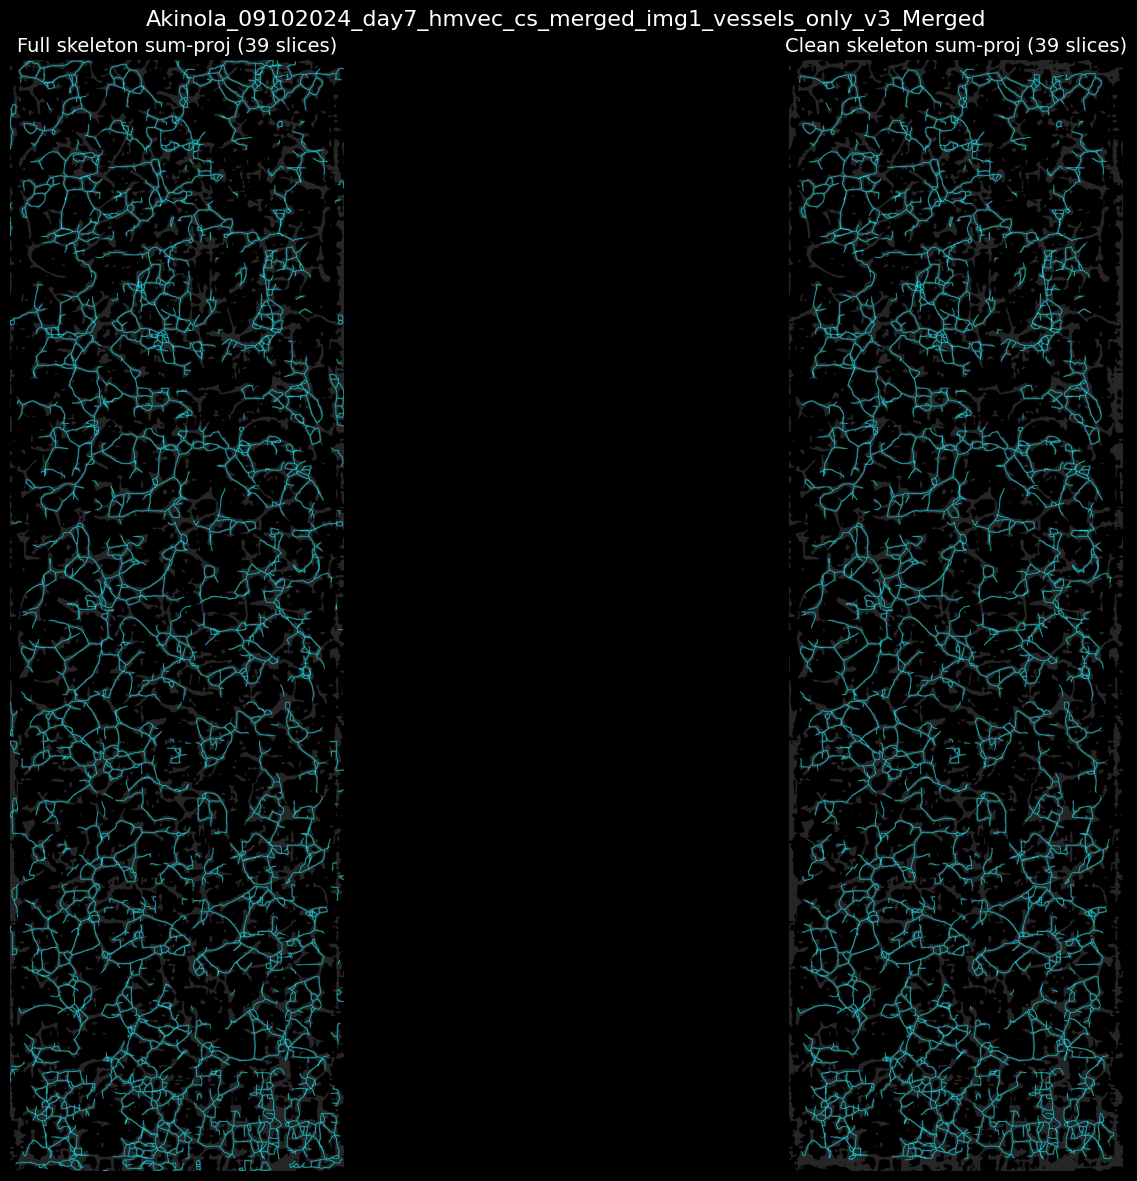

In [61]:
# ── Skeleton sum-projection overlaid on segmentation ──────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.ndimage import maximum_filter

nz = segmentation.shape[0]

# Sum-project skeletons along z
skel_sum = np.sum(skeleton.astype(np.float32), axis=0)
clean_skel_sum = np.sum(clean_skeleton.astype(np.float32), axis=0)

# Dilate so thin lines are visible
skel_thick = maximum_filter(skel_sum, size=3)
clean_thick = maximum_filter(clean_skel_sum, size=3)

skel_norm = skel_thick / max(skel_thick.max(), 1)
clean_norm = clean_thick / max(clean_thick.max(), 1)

# Dim segmentation background
seg_max = np.max(segmentation.astype(bool), axis=0).astype(np.float32)

def make_overlay(seg_bg, skel_norm, skel_cmap='cool'):
    cmap_fn = cm.get_cmap(skel_cmap)
    rgb = np.stack([seg_bg * 0.15] * 3, axis=-1)
    mask = skel_norm > 0
    rgb[mask] = cmap_fn(skel_norm[mask])[:, :3]
    return np.clip(rgb, 0, 1)

overlay_full = make_overlay(seg_max, skel_norm, 'cool')
overlay_clean = make_overlay(seg_max, clean_norm, 'cool')

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

axes[0].imshow(overlay_full)
axes[0].set_title(f'Full skeleton sum-proj ({nz} slices)', fontsize=14)
axes[0].axis('off')

axes[1].imshow(overlay_clean)
axes[1].set_title(f'Clean skeleton sum-proj ({nz} slices)', fontsize=14)
axes[1].axis('off')

plt.suptitle(view_dir.name, fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_620256\3711151540.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


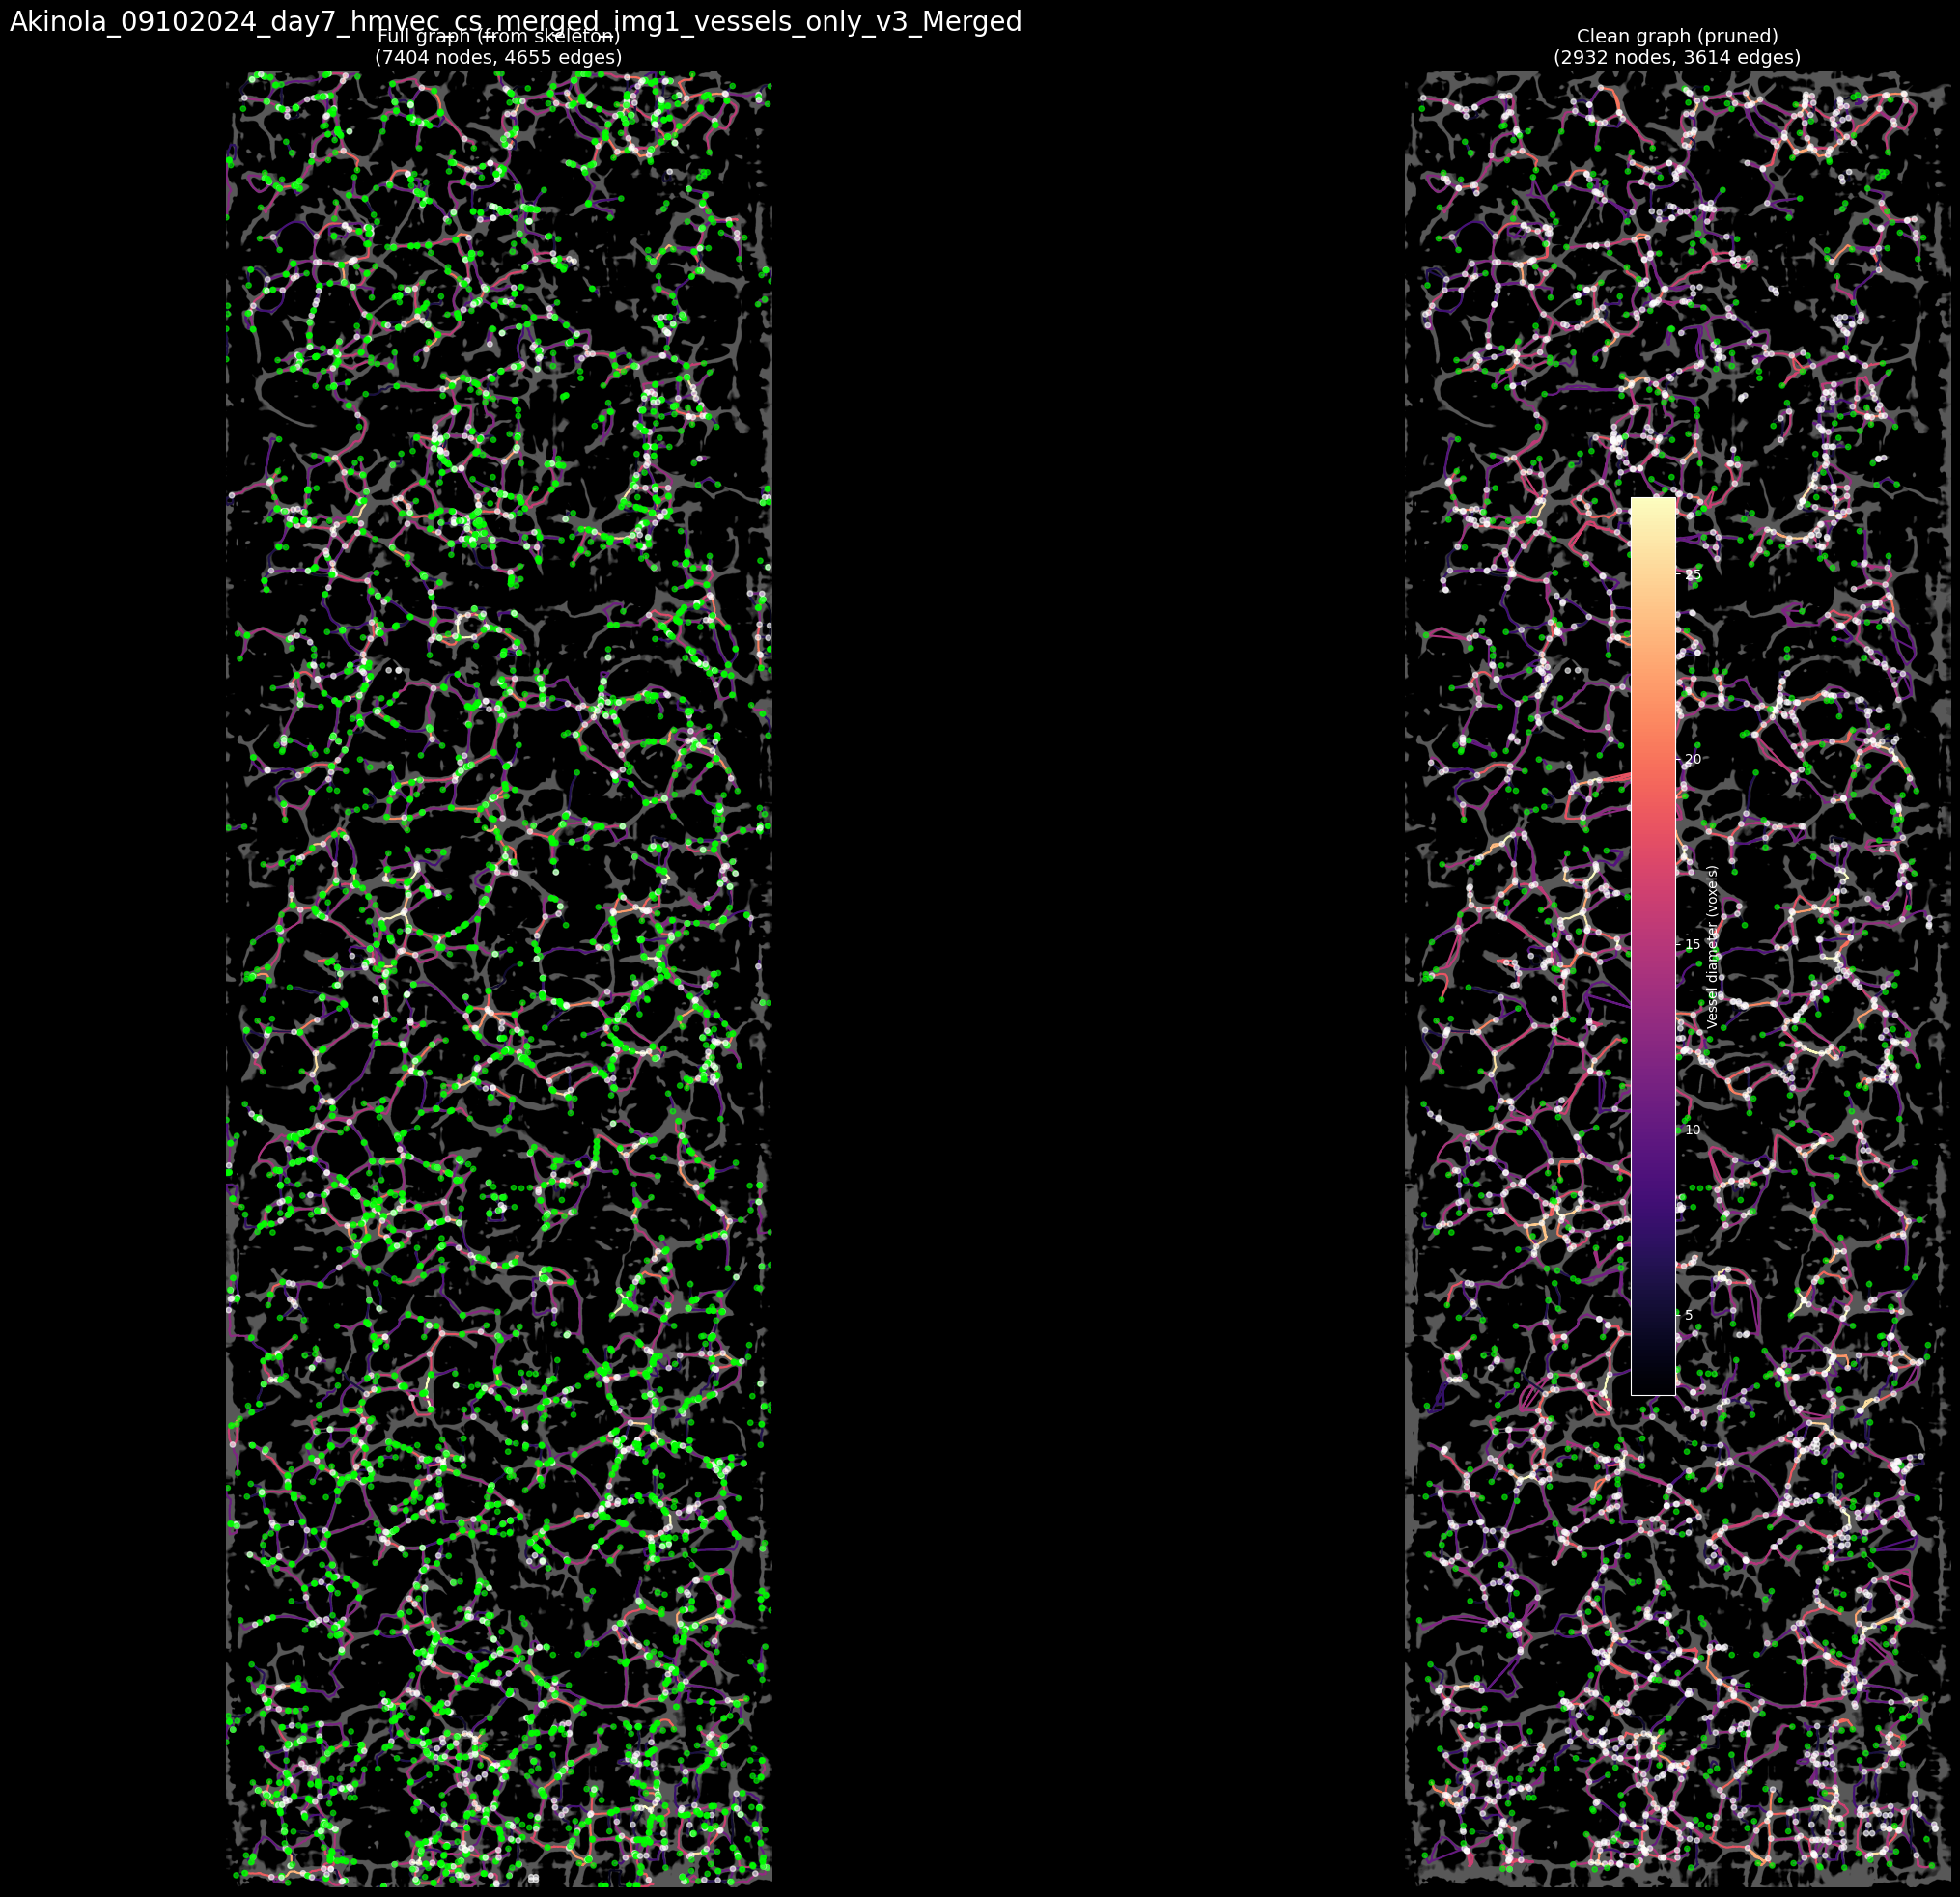

In [ ]:
# ── Graph overlays on segmentation (full skeleton vs clean skeleton) ───────────
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from scipy.ndimage import distance_transform_edt as edt_func
import sknw
import pickle

seg_bool = segmentation.astype(bool)
binary_edt = edt_func(seg_bool)

# ── Build full graph from the (unpruned) skeleton volume ──────────────────
full_graph = sknw.build_sknw(skeleton.astype(bool))

# ── Load clean graph from pkl (pruned) ────────────────────────────────────
graph_files = sorted(view_dir.glob("*_clean_graph.pkl"))
if graph_files:
    with open(graph_files[0], "rb") as f:
        clean_graph = pickle.load(f)
else:
    clean_graph = sknw.build_sknw(clean_skeleton.astype(bool))

# ── Per-edge diameters from 3D EDT ────────────────────────────────────────
def edge_diameters_for(g):
    diams = []
    for u, v in g.edges():
        try:
            pts = np.clip(g[u][v]['pts'].astype(int),
                          [0, 0, 0], [s - 1 for s in binary_edt.shape])
            radii = binary_edt[pts[:, 0], pts[:, 1], pts[:, 2]]
            diams.append(float(np.median(radii)) * 2.0)
        except (KeyError, IndexError):
            diams.append(0.0)
    return diams

full_diams = edge_diameters_for(full_graph)
clean_diams = edge_diameters_for(clean_graph)

all_diams = [d for d in full_diams + clean_diams if d > 0]
vmin = np.percentile(all_diams, 5) * 0.5 if all_diams else 0
vmax = np.percentile(all_diams, 95) if all_diams else 1

norm = Normalize(vmin=vmin, vmax=vmax)
sm = cm.ScalarMappable(norm=norm, cmap=cm.magma)

# ── Very dim grey background (same style as skeleton overlay cell) ────────
seg_max = np.max(seg_bool, axis=0).astype(np.float32)
background = np.stack([seg_max * 0.15] * 3, axis=-1)

# ── Helper: draw graph edges + nodes on a dim background ─────────────────
def draw_graph(ax, g, diams, title):
    ax.imshow(background)
    for (u, v), diam in zip(g.edges(), diams):
        try:
            pts = g[u][v]['pts'].astype(int)
            ax.plot(pts[:, 2], pts[:, 1], color=sm.to_rgba(diam), linewidth=2.0, solid_capstyle='round')
        except (KeyError, IndexError):
            continue
    nx_x, nx_y, nc = [], [], []
    for node in g.nodes():
        pos = g.nodes[node]['pts']
        if pos.ndim > 1:
            pos = pos[0]
        nx_x.append(pos[2]); nx_y.append(pos[1])
        nc.append('lime' if g.degree(node) == 1 else 'white')
    if nx_x:
        ax.scatter(nx_x, nx_y, c=nc, s=20, alpha=0.8, zorder=5)
    ax.set_title(f'{title}\n({g.number_of_nodes()} nodes, {g.number_of_edges()} edges)', fontsize=14)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(30, 20))
draw_graph(axes[0], full_graph, full_diams, 'Full graph (from skeleton)')
draw_graph(axes[1], clean_graph, clean_diams, 'Clean graph (pruned)')
fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02, label='Vessel diameter (µm)')
plt.suptitle(view_dir.name, fontsize=20)
plt.tight_layout()
plt.show()